In [13]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import re

In [14]:
# logfile = '/mnt/scratch/baburish/doublepulse/gnn/Analysis/logs/22644slurm_GAT.log'
logfile = '/mnt/scratch/baburish/doublepulse/gnn/Analysis/trained_model/GAT_0p3dropout_weightdecay5e4_64batchsize_focalloss2p0/c.log'
logfile = '/mnt/scratch/baburish/doublepulse/gnn/Analysis/trained_model/GAT_0p5dropout/a.log'
logfile = '/mnt/scratch/baburish/doublepulse/gnn/Analysis/c1.log'
with open(logfile, 'r') as f:
    lines = f.readlines()

In [15]:
#Epoch   3 | Train: 0.7505 | Val: 0.7251 | AUC: 0.7451 | Best: 0.7451
total_epochs = 110
epochs = []
train_loss = []
val_loss = []
auc = []
pattern = r"Epoch\s+(\d+)\s+\|\s+Train:\s+([\d\.]+)\s+\|\s+Val:\s+([\d\.]+)\s+\|\s+AUC:\s+([\d\.]+)\s+\|\s+LR:\s+([\d\.eE+-]+)\s+\|\s+Best:\s+([\d\.]+)"
for line in lines:
    match = re.search(pattern, line)
    if match:
        epochs.append(int(match.group(1)))
        train_loss.append(float(match.group(2)))
        val_loss.append(float(match.group(3)))
        auc.append(float(match.group(4)))

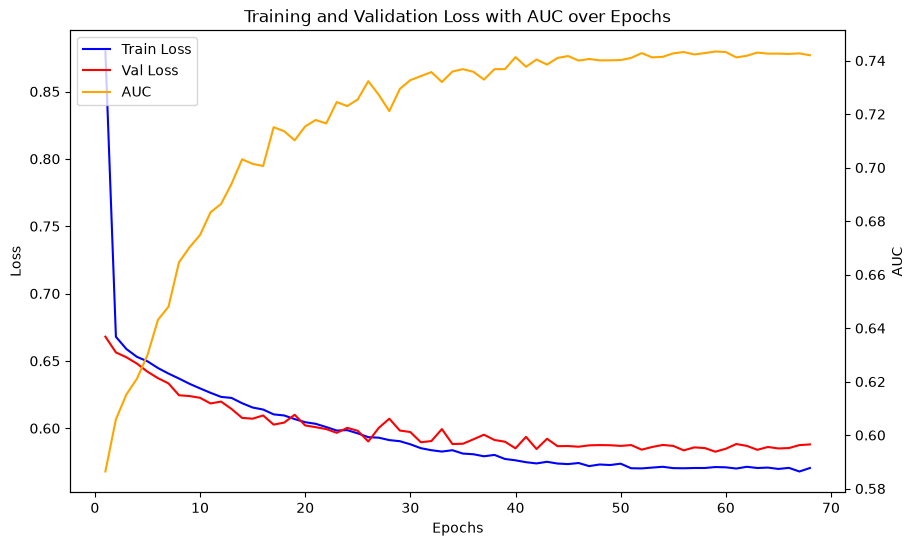

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epochs, train_loss, label='Train Loss', color='blue')
ax.plot(epochs, val_loss, label='Val Loss', color='red')
# ax.axvline(val_loss.index(min(val_loss)), color='green', linestyle='--', label='Best Val Loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax2 = ax.twinx()
ax2.plot(epochs, auc, label='AUC', color='orange')
ax2.set_ylabel('AUC')
ax.set_title('Training and Validation Loss with AUC over Epochs')
# Combine legends from both axes
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')
plt.show()

In [17]:
for i, j, k, l in zip(epochs, train_loss, val_loss, auc):
    print(f"Epoch: {i}, Train Loss: {j}, Val Loss: {k}, AUC: {l}")

Epoch: 1, Train Loss: 0.8797, Val Loss: 0.668, AUC: 0.5864
Epoch: 2, Train Loss: 0.6679, Val Loss: 0.6563, AUC: 0.6059
Epoch: 3, Train Loss: 0.6588, Val Loss: 0.6527, AUC: 0.6152
Epoch: 4, Train Loss: 0.653, Val Loss: 0.648, AUC: 0.6211
Epoch: 5, Train Loss: 0.6497, Val Loss: 0.642, AUC: 0.6299
Epoch: 6, Train Loss: 0.6447, Val Loss: 0.6372, AUC: 0.6431
Epoch: 7, Train Loss: 0.6406, Val Loss: 0.6333, AUC: 0.648
Epoch: 8, Train Loss: 0.6369, Val Loss: 0.6245, AUC: 0.6646
Epoch: 9, Train Loss: 0.633, Val Loss: 0.6239, AUC: 0.6702
Epoch: 10, Train Loss: 0.6296, Val Loss: 0.6226, AUC: 0.6748
Epoch: 11, Train Loss: 0.6263, Val Loss: 0.6184, AUC: 0.6833
Epoch: 12, Train Loss: 0.6233, Val Loss: 0.6198, AUC: 0.6864
Epoch: 13, Train Loss: 0.6225, Val Loss: 0.6143, AUC: 0.694
Epoch: 14, Train Loss: 0.6186, Val Loss: 0.6077, AUC: 0.7031
Epoch: 15, Train Loss: 0.6154, Val Loss: 0.6071, AUC: 0.7014
Epoch: 16, Train Loss: 0.6139, Val Loss: 0.6095, AUC: 0.7006
Epoch: 17, Train Loss: 0.6103, Val Loss:

In [18]:
max(auc)

0.7434

Epoch: 34, Train Loss: 0.6434, Val Loss: 0.681, AUC: 0.7888
Epoch: 35, Train Loss: 0.6415, Val Loss: 0.6763, AUC: 0.7878
Epoch: 36, Train Loss: 0.6402, Val Loss: 0.6776, AUC: 0.7882
Epoch: 37, Train Loss: 0.6407, Val Loss: 0.6754, AUC: 0.7931
Epoch: 38, Train Loss: 0.6367, Val Loss: 0.6885, AUC: 0.7875
Epoch: 39, Train Loss: 0.6369, Val Loss: 0.692, AUC: 0.7831
Epoch: 40, Train Loss: 0.6338, Val Loss: 0.678, AUC: 0.7896
Epoch: 41, Train Loss: 0.6323, Val Loss: 0.6913, AUC: 0.7874
Epoch: 42, Train Loss: 0.6302, Val Loss: 0.6896, AUC: 0.7885
Epoch: 43, Train Loss: 0.6315, Val Loss: 0.6898, AUC: 0.7868
Epoch: 44, Train Loss: 0.6284, Val Loss: 0.6917, AUC: 0.7887
Epoch: 45, Train Loss: 0.6276, Val Loss: 0.6897, AUC: 0.7878
Epoch: 46, Train Loss: 0.627, Val Loss: 0.6872, AUC: 0.7892
Epoch: 47, Train Loss: 0.6247, Val Loss: 0.6951, AUC: 0.7875

python infer.py --model_path /mnt/scratch/baburish/doublepulse/gnn/Analysis/trained_model/GAT_0p3dropout_weightdecay5e4_64batchsize_focalloss3p0/hybrid_weights.pt --scaler_path /mnt/scratch/baburish/doublepulse/gnn/Analysis/trained_model/GAT_0p3dropout_weightdecay5e4_64batchsize_focalloss3p0/pca_scaler.joblib --nue_dbs /mnt/research/IceCube/lownutau/gemini_moreMC_sqlite/nue_test/*65TeV* --tau_dbs /mnt/research/IceCube/lownutau/gemini_moreMC_sqlite/nutau_test/*65TeV* --geo data/geometry_clean.csv --save_dir trained_model/infer_GAT_0p3dropout_weightdecay5e4_64batchsize_focalloss3p --max_events 10000

python infer.py --model_path /mnt/scratch/baburish/doublepulse/gnn/Analysis/trained_model/GAT_0p3dropout_weightdecay5e4_64batchsize_focalloss2p0/hybrid_weights.pt --scaler_path /mnt/scratch/baburish/doublepulse/gnn/Analysis/trained_model/GAT_0p3dropout_weightdecay5e4_64batchsize_focalloss2p0/pca_scaler.joblib --nue_dbs /mnt/research/IceCube/lownutau/gemini_moreMC_sqlite/nue_test/*65TeV* --tau_dbs /mnt/research/IceCube/lownutau/gemini_moreMC_sqlite/nutau_test/*65TeV* --geo data/geometry_clean.csv --save_dir trained_model/infer_GAT_0p3dropout_weightdecay5e4_64batchsize_focalloss2p --max_events 10000